<a href="https://colab.research.google.com/github/mohit-kumar396/Machine-Learning-Project/blob/main/Loan_Prediction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Information**

   **Dream Housing Finance company deals in all home loans. They have presence across all urban, semi urban and rural areas. Customer first apply for home loan after that company validates the customer eligibility for loan. Company wants to automate the loan eligibility process (real time) based on customer detail provided while filling online application form. These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History and others. To automate this process, they have given a problem to identify the customers segments, those are eligible for loan amount so that they can specifically target these customers.**
   
   **This is a standard supervised classification task.A classification problem where we have to predict whether a loan would be approved or not. Below is the dataset attributes with description.**
   
**Variable** | **Description**
----------|--------------
**Loan_ID** | **Unique Loan ID**
**Gender** | **Male/ Female**
**Married** | **Applicant married (Y/N)**
**Dependents** | **Number of dependents**
**Education** | **Applicant Education** **(Graduate/ Under Graduate)**
**Self_Employed** | **Self employed (Y/N)**
**ApplicantIncome** | **Applicant income**
**CoapplicantIncome** | **Coapplicant income**
**LoanAmount** | **Loan amount in thousands**
**Loan_Amount_Term** | **Term of loan in months**
**Credit_History** | **credit history meets guidelines**
**Property_Area** | **Urban/ Semi Urban/ Rural**
**Loan_Status** | **Loan approved (Y/N)**

**Import Modules**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#**Dataset Load**

In [ ]:
df = pd.read_csv("Loan Prediction Dataset.csv")
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


#**dataset Preprocessing**

In [ ]:
# find the null values
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
# fill the missing values for numerical terms - mean

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())

In [ ]:
# fill the missing values for categorical terms - mode

df['Gender'] = df["Gender"].fillna(df['Gender'].mode()[0])
df['Married'] = df["Married"].fillna(df['Married'].mode()[0])
df['Dependents'] = df["Dependents"].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df["Self_Employed"].fillna(df['Self_Employed'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


#**Exploratory Data Analysis**

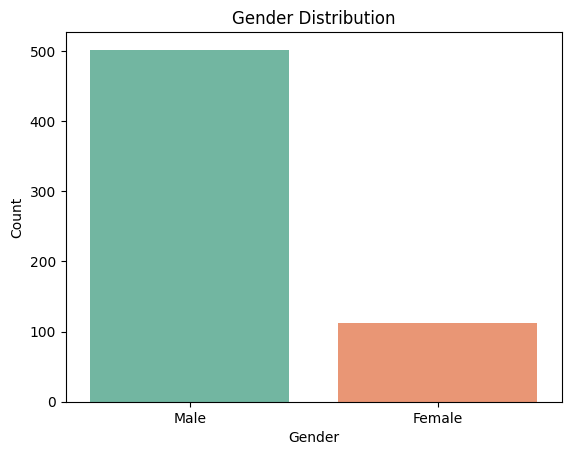

In [ ]:
# categorical attributes visualization

sns.countplot(x='Gender', data=df, hue='Gender', palette='Set2', legend=False)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

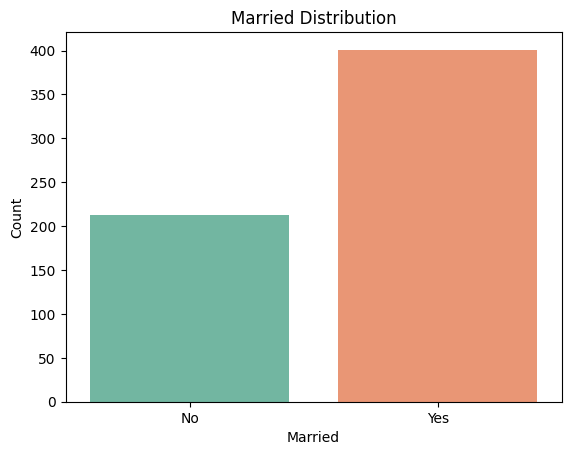

In [ ]:
sns.countplot(x='Married', data=df, hue='Married', palette='Set2', legend=False)
plt.title('Married Distribution')
plt.xlabel('Married')
plt.ylabel('Count')
plt.show()

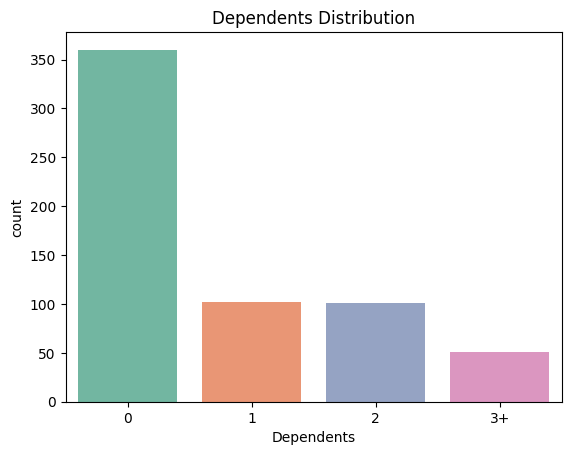

In [ ]:
sns.countplot(x='Dependents', data=df, hue='Dependents', palette='Set2', legend=False)
plt.title('Dependents Distribution')
plt.xlabel('Dependents')
plt.ylabel('count')
plt.show()

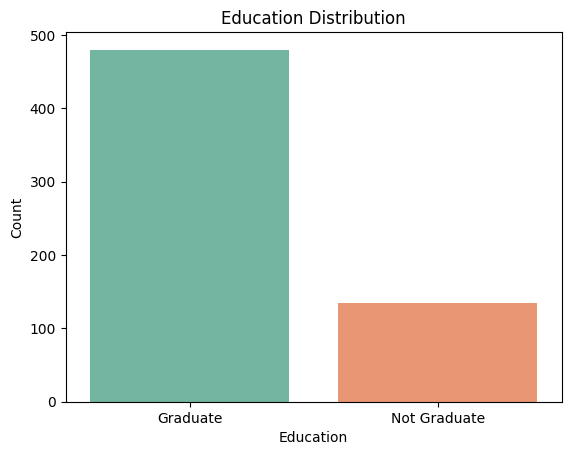

In [ ]:
sns.countplot(x='Education', data=df, hue='Education', palette='Set2', legend=False)
plt.title('Education Distribution')
plt.xlabel('Education')
plt.ylabel('Count')
plt.show()

Text(0, 0.5, 'count')

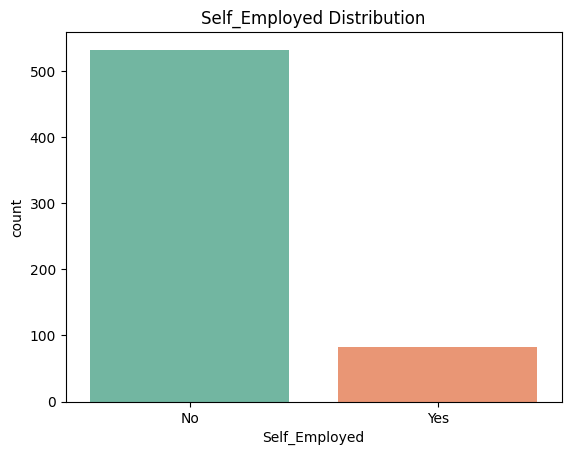

In [ ]:
sns.countplot(x='Self_Employed', data=df, hue='Self_Employed', palette='Set2', legend=False)
plt.title('Self_Employed Distribution')
plt.xlabel('Self_Employed')
plt.ylabel('count')

Text(0, 0.5, 'count')

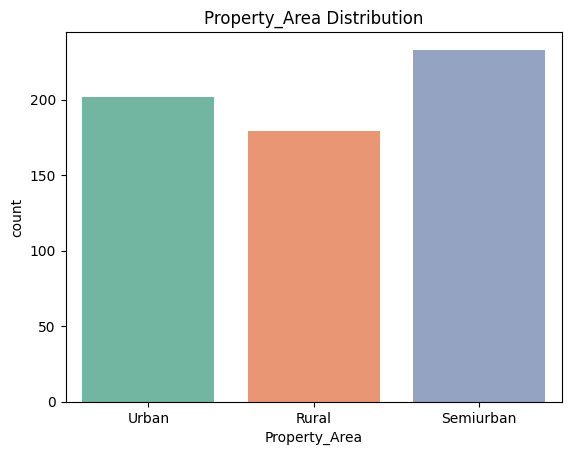

In [ ]:
sns.countplot(x='Property_Area', data=df, hue='Property_Area', palette='Set2', legend=False)
plt.title('Property_Area Distribution')
plt.xlabel('Property_Area')
plt.ylabel('count')

Text(0, 0.5, 'count')

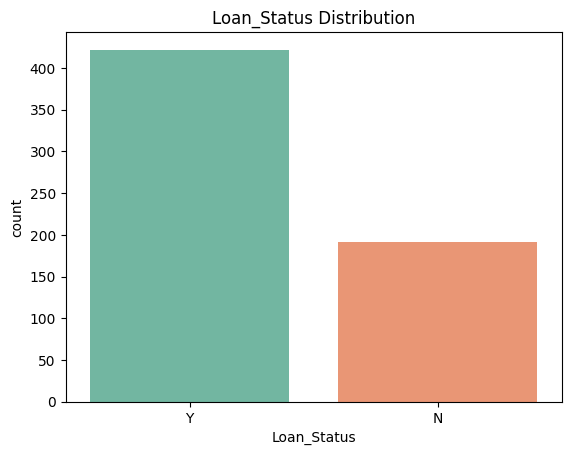

In [ ]:
sns.countplot(x='Loan_Status', data=df, hue='Loan_Status', palette='Set2', legend=False)
plt.title('Loan_Status Distribution')
plt.xlabel('Loan_Status')
plt.ylabel('count')

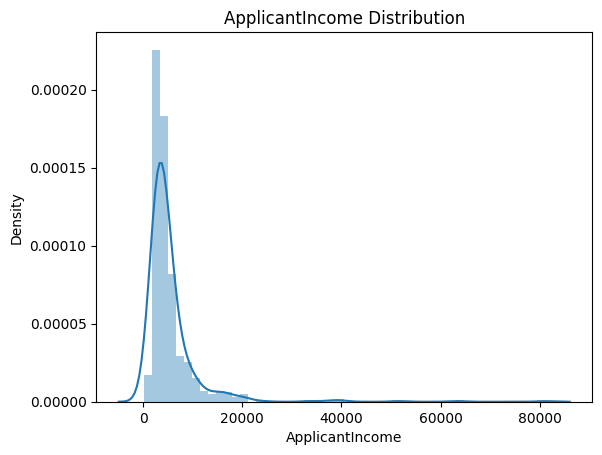

In [ ]:
# numerical attributes visualization
sns.distplot(df['ApplicantIncome'])
plt.title('ApplicantIncome Distribution')
plt.show()

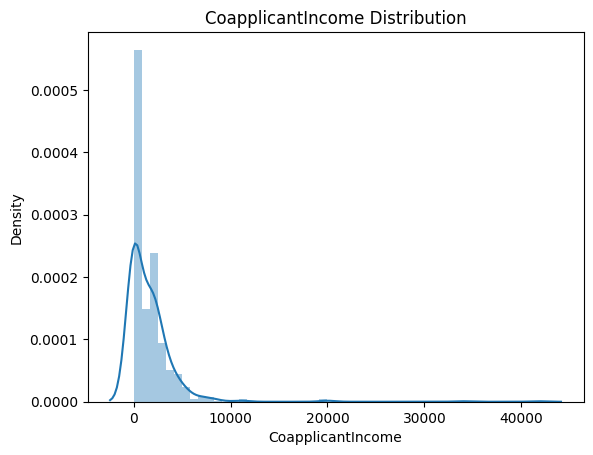

In [ ]:
sns.distplot(df['CoapplicantIncome'])
plt.title('CoapplicantIncome Distribution')
plt.show()

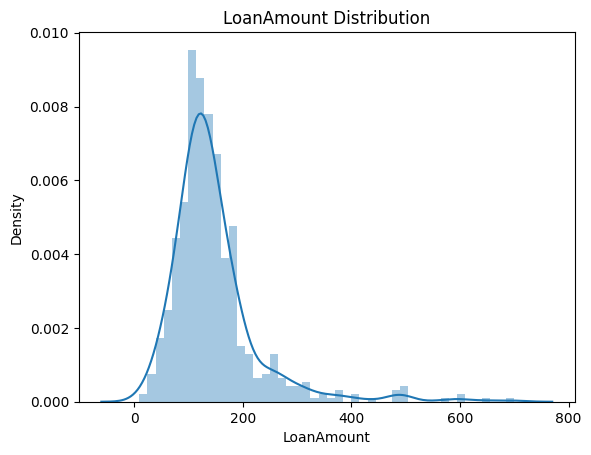

In [ ]:
sns.distplot(df["LoanAmount"])
plt.title('LoanAmount Distribution')
plt.show()

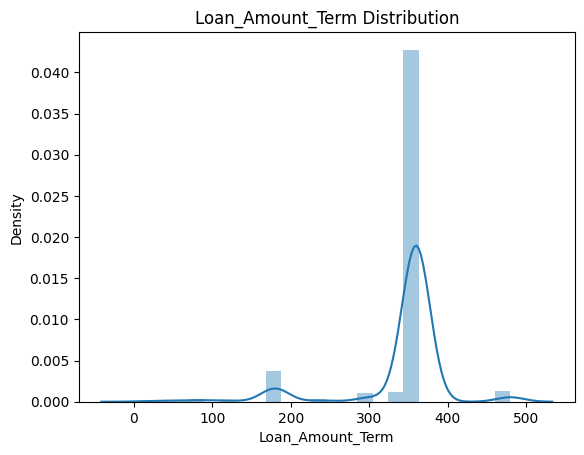

In [ ]:
sns.distplot(df["Loan_Amount_Term"])
plt.title('Loan_Amount_Term Distribution')
plt.show()

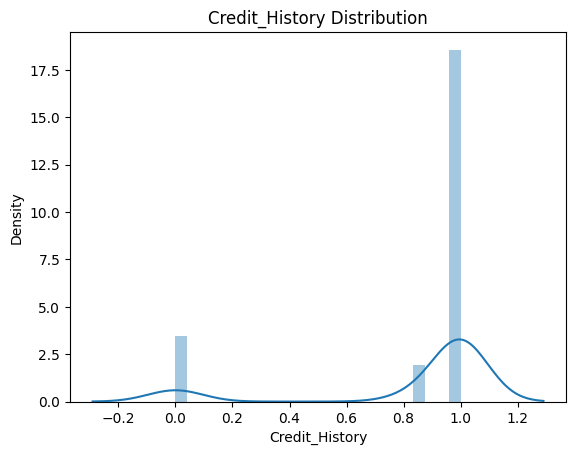

In [ ]:
sns.distplot(df["Credit_History"])
plt.title('Credit_History Distribution')
plt.show()

#**Creation of new attributes**

In [ ]:
# Total Income

df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0


#**Log Transformation**

<Axes: xlabel='ApplicantIncomeLog', ylabel='Density'>

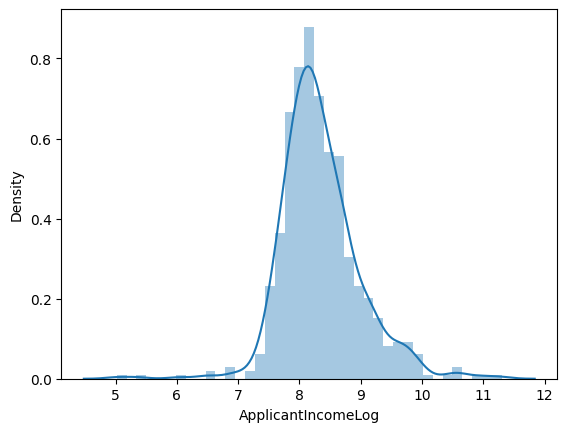

In [ ]:
# apply log transformation to the attributes

df['ApplicantIncomeLog'] = np.log(df['ApplicantIncome']+1)
sns.distplot(df["ApplicantIncomeLog"])

<Axes: xlabel='CoapplicantIncomeLog', ylabel='Density'>

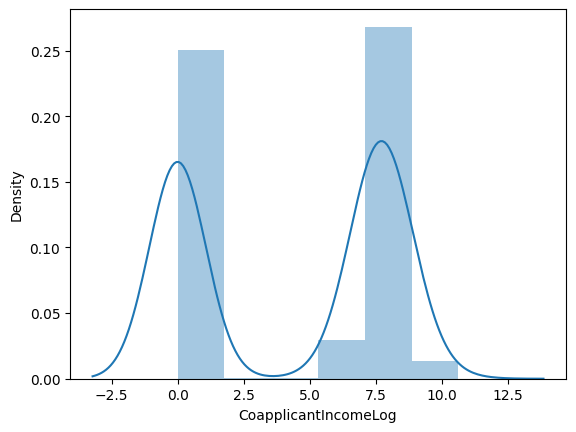

In [ ]:
df['CoapplicantIncomeLog'] = np.log(df['CoapplicantIncome']+1)
sns.distplot(df["CoapplicantIncomeLog"])

<Axes: xlabel='LoanAmountLog', ylabel='Density'>

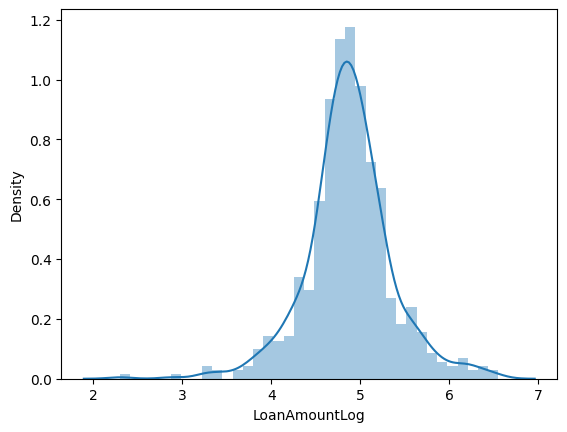

In [ ]:
df['LoanAmountLog'] = np.log(df['LoanAmount']+1)
sns.distplot(df["LoanAmountLog"])

<Axes: xlabel='Loan_Amount_Term_Log', ylabel='Density'>

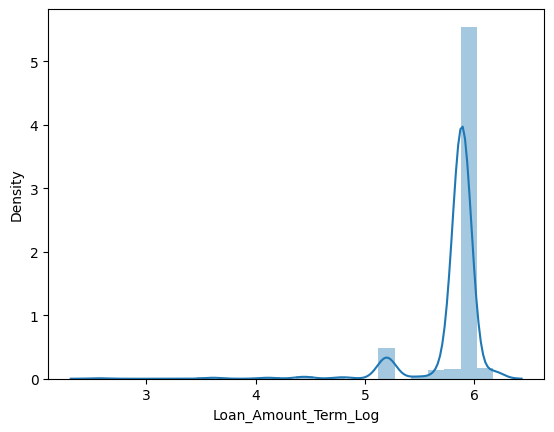

In [ ]:
df['Loan_Amount_Term_Log'] = np.log(df['Loan_Amount_Term']+1)
sns.distplot(df["Loan_Amount_Term_Log"])

<Axes: xlabel='Total_Income_Log', ylabel='Density'>

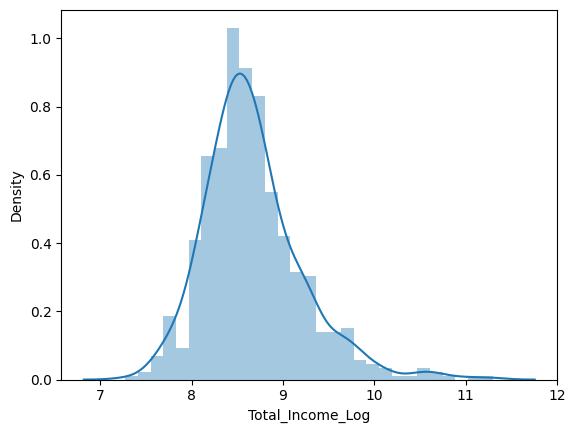

In [ ]:
df['Total_Income_Log'] = np.log(df['Total_Income']+1)
sns.distplot(df["Total_Income_Log"])

#**Coorelation Matrix**

<Axes: >

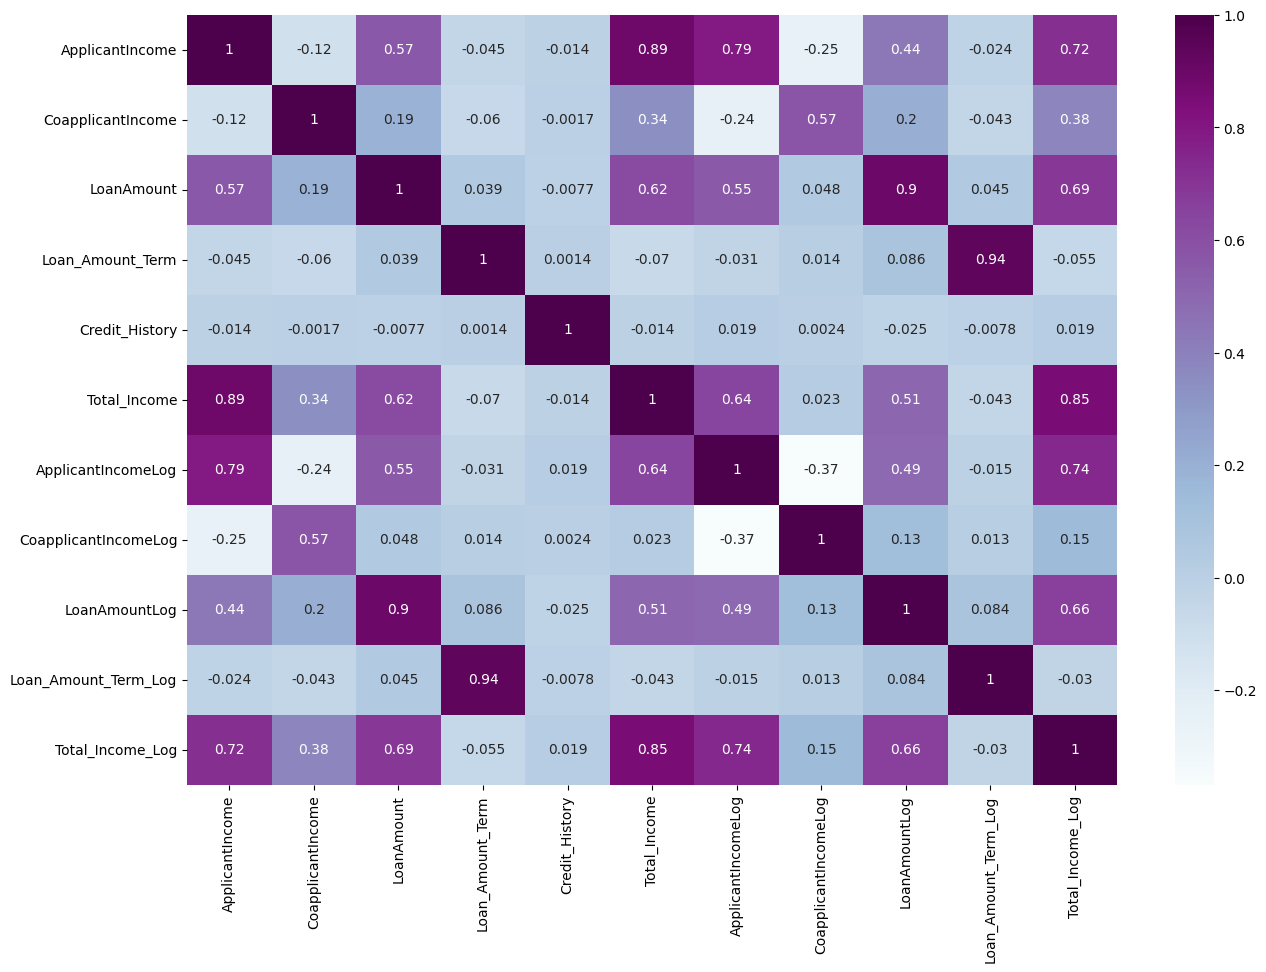

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap="BuPu")

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,ApplicantIncomeLog,CoapplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_Income_Log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0,8.674197,0.000000,4.993232,5.888878,8.674197
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0,8.430327,7.319202,4.859812,5.888878,8.714732
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0,8.006701,0.000000,4.204693,5.888878,8.006701
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0,7.857094,7.765993,4.795791,5.888878,8.505525
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0,8.699681,0.000000,4.955827,5.888878,8.699681


In [ ]:
# drop unnecessary columns
cols = ['ApplicantIncome', 'CoapplicantIncome', "LoanAmount", "Loan_Amount_Term", "Total_Income", 'Loan_ID', 'CoapplicantIncomeLog']
df = df.drop(columns=cols, axis=1)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_Income_Log
0,Male,No,0,Graduate,No,1.0,Urban,Y,8.674197,4.993232,5.888878,8.674197
1,Male,Yes,1,Graduate,No,1.0,Rural,N,8.430327,4.859812,5.888878,8.714732
2,Male,Yes,0,Graduate,Yes,1.0,Urban,Y,8.006701,4.204693,5.888878,8.006701
3,Male,Yes,0,Not Graduate,No,1.0,Urban,Y,7.857094,4.795791,5.888878,8.505525
4,Male,No,0,Graduate,No,1.0,Urban,Y,8.699681,4.955827,5.888878,8.699681


In [ ]:
df.head(20)

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_Income_Log
0,Male,No,0,Graduate,No,1.000000,Urban,Y,8.674197,4.993232,5.888878,8.674197
1,Male,Yes,1,Graduate,No,1.000000,Rural,N,8.430327,4.859812,5.888878,8.714732
2,Male,Yes,0,Graduate,Yes,1.000000,Urban,Y,8.006701,4.204693,5.888878,8.006701
3,Male,Yes,0,Not Graduate,No,1.000000,Urban,Y,7.857094,4.795791,5.888878,8.505525
4,Male,No,0,Graduate,No,1.000000,Urban,Y,8.699681,4.955827,5.888878,8.699681
5,Male,Yes,2,Graduate,Yes,1.000000,Urban,Y,8.597482,5.590987,5.888878,9.170976
6,Male,Yes,0,Not Graduate,No,1.000000,Urban,Y,7.755339,4.564348,5.888878,8.255828
7,Male,Yes,3+,Graduate,No,0.000000,Semiurban,N,8.018625,5.068904,5.888878,8.619930
8,Male,Yes,2,Graduate,No,1.000000,Urban,Y,8.295798,5.129899,5.888878,8.618485
9,Male,Yes,1,Graduate,No,1.000000,Semiurban,N,9.460476,5.857933,5.888878,10.077861


In [ ]:
from sklearn.preprocessing import LabelEncoder
cols = ['Gender',"Married","Education",'Self_Employed',"Property_Area","Loan_Status","Dependents"]
le = LabelEncoder()
for col in cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head(20)

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_Income_Log
0,1,0,0,0,0,1.000000,2,1,8.674197,4.993232,5.888878,8.674197
1,1,1,1,0,0,1.000000,0,0,8.430327,4.859812,5.888878,8.714732
2,1,1,0,0,1,1.000000,2,1,8.006701,4.204693,5.888878,8.006701
3,1,1,0,1,0,1.000000,2,1,7.857094,4.795791,5.888878,8.505525
4,1,0,0,0,0,1.000000,2,1,8.699681,4.955827,5.888878,8.699681
5,1,1,2,0,1,1.000000,2,1,8.597482,5.590987,5.888878,9.170976
6,1,1,0,1,0,1.000000,2,1,7.755339,4.564348,5.888878,8.255828
7,1,1,3,0,0,0.000000,1,0,8.018625,5.068904,5.888878,8.619930
8,1,1,2,0,0,1.000000,2,1,8.295798,5.129899,5.888878,8.618485
9,1,1,1,0,0,1.000000,1,0,9.460476,5.857933,5.888878,10.077861


#**Train-Test Split**

In [ ]:
# specify input and output attributes

X = df.drop(columns=['Loan_Status'], axis=1)
y = df['Loan_Status']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#**Model Training**

In [ ]:
# classify function
from sklearn.model_selection import cross_val_score
def classify(model, x, y):
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    model.fit(x_train, y_train)
    print("Accuracy is", model.score(x_test, y_test)*100)
    # cross validation - it is used for better validation of model
    # eg: cv-5, train-4, test-1
    score = cross_val_score(model, x, y, cv=5)
    print("Cross validation is",np.mean(score)*100)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
classify(model, X, y)

Accuracy is 77.27272727272727
Cross validation is 80.9462881514061


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
classify(model, X, y)

Accuracy is 72.72727272727273
Cross validation is 71.01559376249502


In [ ]:
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
model = RandomForestClassifier()
classify(model, X, y)

Accuracy is 77.92207792207793
Cross validation is 78.83113421298147


In [ ]:
model = ExtraTreesClassifier()
classify(model, X, y)

Accuracy is 75.32467532467533
Cross validation is 77.20378515260562


#**Hyperparameter tuning**

In [ ]:
model = RandomForestClassifier(n_estimators=100, min_samples_split=25, max_depth=7, max_features=1)
classify(model, X, y)

Accuracy is 76.62337662337663
Cross validation is 80.13194722111156


#**Confusion Matrix**

In [ ]:
model = RandomForestClassifier()
model.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[23, 31],
       [ 5, 95]])

<Axes: >

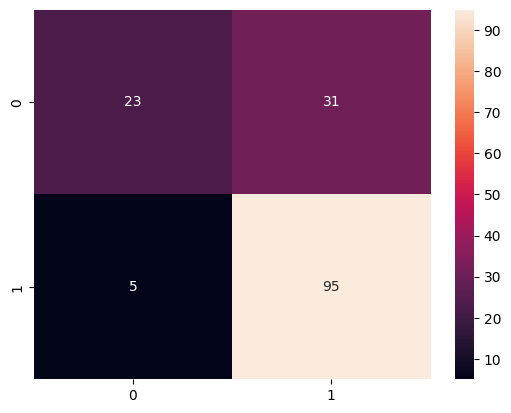

In [ ]:
sns.heatmap(cm, annot=True)